# <u>AdaBoosting</u>

### Prerequisites:

* <a href="../6.Descision Trees Classifier/Descision Trees Classifier.ipynb">Check out the notebookes on Decision Tree Classifier</a>
* <a href="../7.Random Forest Classifier/Random Forest Classification.ipynb">Check out the notebooks on Random Forest Classification</a>

## Topics

* [1. What is Boosting?](#what)
* [2. Boosting vs. Bagging](#vs)
* [3. Adaptive Boosting Regression and Classification](#ada)


<a href="../../1.Regression/9.AdaBoost Regressor/Adaboost Regression.ipynb">Check out the notebook on Adaboost Regression for more code</a>



In [9]:
import numpy as np # for arrays and random numbers
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting
from plotly.subplots import make_subplots # for plotting as a grid

from sklearn.tree import (
    DecisionTreeClassifier, # for Classification Trees
    DecisionTreeRegressor # for Regression Trees
)

from sklearn.ensemble import (
    AdaBoostClassifier, # for AdaBoost in Classification
    AdaBoostRegressor, # for Adaboost in Regression
    GradientBoostingClassifier, # Gradient Boosting Classification
    GradientBoostingRegressor, # Gradient Boosting Regression
    HistGradientBoostingClassifier, # Histogram-based Gradient Boosting for Classification
    HistGradientBoostingRegressor, # Histogram-based Gradient Boosting for Regression
    RandomForestClassifier, # for Random Forest Classification
    RandomForestRegressor # for Random Forest Regression
)

# XGBoost
#from xgboost import XGBClassifier, XGBRegressor

# LightGBM
#from lightgbm import LGBMClassifier, LGBMRegressor

# CatBoost
#from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.datasets import make_classification # toy data for classification
from sklearn.datasets import make_regression # toy data for regression

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score

print("Setup complete")

Setup complete


<a class="anchor" id="what"></a>
# 1. What is Boosting?

- Boosting is an ensemble learning technique that combines many weak learners into a strong predictive model
- **Idea:** <u>Sequentially</u> apply a weak learner to <u>modified versions of the training data</u> with more focus on difficult observations
- Typical weak learners are decision trees and tree stumps (1-level decision trees)
- Boosting can be used fpr Classification, Regression and multiclass porblemns
- Weak learners are a prediction rule with a correct classification rate only slightly better than random guessing (so above 50% accuracy)

<a class="anchor" id="vs"></a>
# 2. Boosting vs. Bagging


<div style="display:flex; gap:20px;">

<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Bagging / Random Forests
- Base learners are decision trees
- Base learners are trained independently
- Equal weighting for base learners
- Goal: Mainly reduces variance
- Usually resistant to overfitting



</div>

<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Boosting
- Base learners are (most commonly) weak decision trees 
- Base learners are trained sequentially
- Following base learners focus on errors of previous base learners
- Different weighting for different base learners
- Goal: Reduces both bias and variance
- More prone to overfitting

</div>
</div>

<p align="center">
<img src="pics/1.png" width="500"/>
</p>


<a class="anchor" id="ada"></a>
# 3. Adaptive Boosting (AdaBoost)


- AdaBoost is a classical boosting algorithm primarily designed for binary classification tasks (but also applicable for regression tasks)
- It combines many weak learners to form a strong predictive model
- The base learners are most commonly decision tree stumps (1-level decision trees)
- Base learners are trained sequentially, meaning each learner depends on the performance of the previous ones
- During training, observations that were misclassified receive higher weights in the next iteration
- As a result, subsequent learners focus more strongly on difficult or previously misclassified samples
- Each base learner contributes to the final prediction with a weight proportional to its predictive accuracy
- AdaBoost aims to reduce both bias and variance, often achieving high predictive performance
- Since the model focuses heavily on hard-to-classify observations, it can be more prone to overfitting, especially in noisy datasets
- A weak learner is defined as a model that performs only slightly better than random guessing (i.e., accuracy greater than 50% in binary classification)

### Main Mechanism
0. Assume binary target $y \in \{-1,+1\}$ and $M$ weak base learners (e.g. tree stumps)
1. Initialize equal observation weights
2. Train weak classifier
3. Increase weights of misclassified observations
4. Train next classifier on reweighted data
5. Combine classifiers using weighted voting.

The final model is: $$f(x)=\sum_{m=1}^M \beta^{[m]} b^{[m]}(x)$$
 and the discrete prediction function is $$h(x)=\text{sign}(f(x)) \in \{-1,+1\}$$

- Number of weak base learners $M$ is a hyperparameter of Adaboost
- $b^{[m]}(x)$: weak base learners
- $\beta^{[m]}$: learner weights based on accuracy

More accurate learners receive larger weights.

**Adaboost algorithm:**

1. Initialize observation weights: $w^{[1](i)}=\frac{1}{n} \hspace{2 mm} \forall i \in \{1,\ldots,n\}$
2. for $m=1 \rightarrow M$ do
    - Fit classifier to training data with weights $w^{[m]}$ and get hard label classifier $\hat{b}^{[m]}$
    - Calculate wieghted in-sample misclassification rate
    $$
    \text{error}^{[m]}=\sum_{i=1}^n w^{[m](i)} \cdot \mathbb{I}_{\{y^{(i)} \neq \hat{b}^{[m]}(x^{(i)})\}} = \text{Sum of weights of missclassified observations}
    $$
    - Compute: $\hat{\beta}^{[m]}=\frac{1}{2}\log\left(\frac{1-\text{error}^{[m]}}{\text{error}^{[m]}}\right)$
    - Set: $w^{[m+1](i)}=w^{[m](i)} \cdot \exp\left(-\hat{\beta}^{[m]} \cdot y^{(i)} \cdot \hat{b}^{[m]}(x^{(i)})\right)$
    - Normalize $w^{[m+1](i)}$ such that $\sum_{i=1}^n w^{[m+1](i)}=1$
3. end for
4. Output: $\hat{f}(x)=\sum_{m=1}^M \hat{\beta}^{[m]} \hat{b}^{[m]}(x)$

<p align="center">
<img src="pics/12.jpg" width="500"/>
</p>

**Random Forests**
- Each tree (base learner) can differ in depth
- Trees are fitted on bootstrap samples of original data 
- Trees do not influence each other
- Trees have equal weights in final prediction

**AdaBoost**
- Every tree is a stump (weak base learner) so have a depth of 1
- Trees are fitted according to errors of previous tree
- Trees do influence each other in a sequential manner
- Trees have unequal weights based on their accuracy
- Trees with higher weights influence final prediction more

---

**AdaBoost contains $M$ tree stumps each with different weights.**

<p align="center">
<img src="pics/3.jpg" width="500"/>
</p>

---

<p align="center">
<img src="pics/4.jpg" width="500"/>
</p>

---

- Each observations becomes same weight so they are equally important at the beginning
<p align="center">
<img src="pics/5.jpg" width="500"/>
</p>

---

- Fit a $M=3$ tree stumps (weak base learners)

- Choose tree stump with lowest weighted Gini index (for binary classification)

- Weighted Gini index = $\frac{\text{n}_L}{n} \text{Gini}_L + \frac{\text{n}_R}{n} \text{Gini}_R $

- This chosen tree stump is denoted as $\hat{b}^{[1]}$

<p align="center">
<img src="pics/6.jpg" width="500"/>
</p>

---

- Compute weight $\hat{\beta}^{[1]}$ (amount of say) of tree stump $\hat{b}^{[1]}$

<p align="center">
<img src="pics/7.jpg" width="500"/>
</p>

---

<p align="center">
<img src="pics/2.jpg" width="500"/>
</p>

---
- Compute new sample weights

- New weights for correct predictions: $w^{[2](i)}=w^{[1](i)} \cdot \exp\left(-\hat{\beta}^{[1]} \cdot 1\right)$

- New weights for incorrect predictions: $w^{[2](i)}=w^{[1](i)} \cdot \exp\left(-\hat{\beta}^{[1]} \cdot (-1)\right)$

- Increase weights of correctly classified data points from previous tree stump ($\hat{b}^{[1]}$)

- Decrease weights of incorrectly classified data points from previous tree stump ($\hat{b}^{[1]}$)


<p align="center">
<img src="pics/8.jpg" width="500"/>
</p>

---

<h5 style="text-align:center;">Two alternatives to fit next tree stump on previous errors</h5>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Make a new collection of samples with duplicate copies of samples with largest sample weights**
- Pick a random number r between 0 and 1 and see where that number falls when treating the sample weights as a distribution
- If r $\in [0,0.07]$ put the sample with the index 1 inside the collection 
- If r $\in [0.07,0.14]$ put the sample with the index 2 inside the collection  
- If r $\in [0.14,0.21]$ put the sample with the index 3 inside the collection 
- If r $\in [0.21,0.70]$ put the sample with the index 4 inside the collection 
- and so on

<p align="center">
<img src="pics/9.jpg" width="500"/>
</p>

- Having drawn a random number $n=8$ times we get following collection
- Get rid of original samples and assign default weights again

<p align="center">
<img src="pics/10.jpg" width="500"/>
</p>


- The range $[0.21,0.70]$ is largest due to the large sample weight of observation 4 (previous misclassified data point by tree stump $\hat{b}^{[1]}$)
- This means we have more copies of observation 4 which results in the next tree stump putting more effort into correctly classifiying that observation

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Use sample weights to compute weighted Gini indexes to determine which variable should split the next stump**

- The weighted Gini index of the tree stump that correcly classifies data points with larger sample weights i.e. previously missclassified data points will be smallest
- Weighted Gini index = $\frac{W^{[m](l)}}{W^{[m](i)}} \text{Gini}_L+ \frac{W^{[m](r)}}{W^{[m](i)}} \text{Gini}_R$
- $W^{[m](l)}$= total sample weight in left node
- $W^{[m](r)}$= total sample weight in right node
- $W^{[m](i)}$= total sample weight  $\approx$ 1 due to normalization

</div>
</div>

--- 

<p align="center">
<img src="pics/11.jpg" width="500"/>
</p>

- Preditc Heart Disease since the total sum of weights of the weak learners with similar predictions are greater than the total sum of weights of the weak learners that predict No Heart Disease

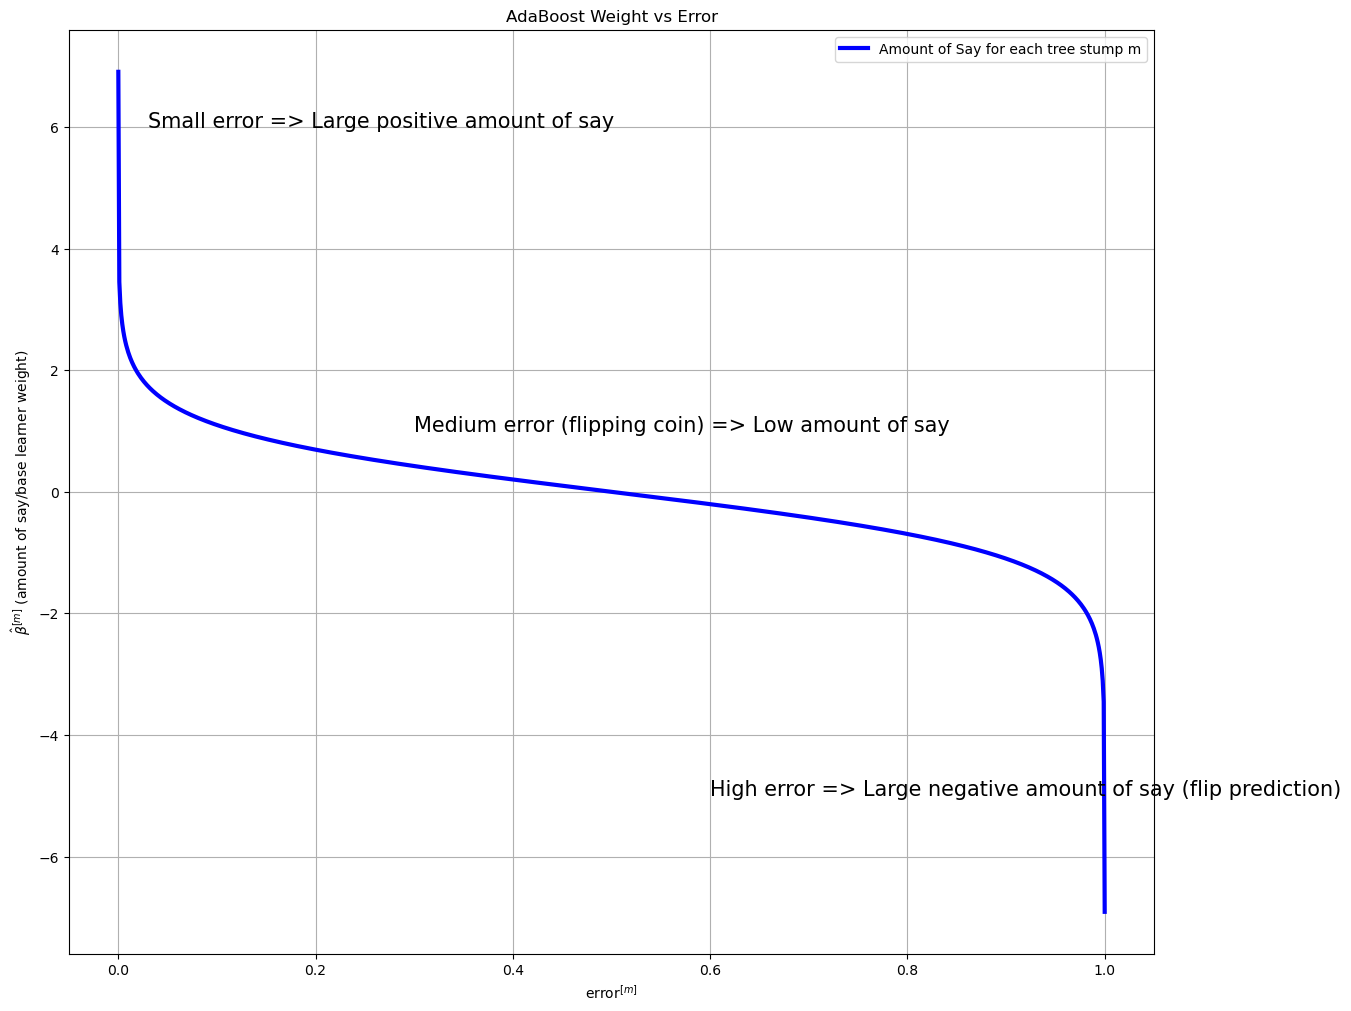

In [10]:
error = np.linspace(1e-6, 1 - 1e-6, 1000) # Avoid exactly 0 and 1
beta_hat = lambda error : 0.5 * np.log((1 - error) / error)

plt.figure(figsize=(14,12))
plt.plot(error, beta_hat(error),label="Amount of Say for each tree stump m",linewidth=3,c="blue")
plt.xlabel(r"$\text{error}^{[m]}$")
plt.ylabel(r"$\hat{\beta}^{[m]}$ (amount of say/base learner weight)")
plt.title("AdaBoost Weight vs Error")
plt.text(0.03,6,"Small error => Large positive amount of say",fontsize=15)
plt.text(0.3,1,"Medium error (flipping coin) => Low amount of say",fontsize=15)
plt.text(0.6,-5,"High error => Large negative amount of say (flip prediction)",fontsize=15)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Create Dataset
X, y = make_classification(n_samples=500,n_features=10,n_informative=5,n_redundant=0,random_state=2223)

# Convert labels from {0,1} -> {-1,+1}
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2223)


# AdaBoost Parameters
M = 50 # number of weak learners
max_depth = 1 # decision tree depth (tree stumps)

n_samples = X_train.shape[0]

# Initialize equal sample weights
weights = np.ones(n_samples) / n_samples

# Store learners and learner weights
learners = []
betas = []

# AdaBoost for Classification with Decision Trees
for m in range(M):

    # 1. Train weak learner using sample weights
    stump = DecisionTreeClassifier(max_depth=max_depth,random_state=2223)

    stump.fit(X_train,y_train,sample_weight=weights) # sample_weight=weights to compute split quality with weighted Gini 

    # Predictions on training set
    y_pred = stump.predict(X_train)

    # 2. Compute weighted classification error
    misclassified = (y_train != y_pred)
    error = np.sum(weights * misclassified)

    # Numerical stability (avoid dividing by 0 later)
    error = np.clip(error, 1e-10, 1 - 1e-10)

    # 3. Compute learner weight beta
    beta = 0.5 * np.log((1 - error) / error)


    # 4. Update sample weights
    weights = weights * np.exp(-beta * y_train * y_pred)

    # Normalize weights
    weights = weights / np.sum(weights)

    # 5. Store learner

    learners.append(stump)
    betas.append(beta)


    # Monitoring
    print(f"Iteration {m+1}")
    print(f"Weighted Error: {error:.4f}")
    print(f"Beta: {beta:.4f}")
    print(f"Max Sample Weight: {weights.max():.4f}")
    print("-" * 50)


# Prediction Function
def adaboost_predict(X, learners, betas):

    scores = np.zeros(X.shape[0])

    for beta, learner in zip(betas, learners):

        predictions = learner.predict(X)

        scores += beta * predictions

    return np.sign(scores)


# Test Predictions
y_test_pred = adaboost_predict(X_test,learners,betas)

accuracy = accuracy_score(y_test, y_test_pred)

print("\nFinal Test Accuracy:", accuracy)

Iteration 1
Weighted Error: 0.2125
Beta: 0.6550
Max Sample Weight: 0.0059
--------------------------------------------------
Iteration 2
Weighted Error: 0.2345
Beta: 0.5914
Max Sample Weight: 0.0125
--------------------------------------------------
Iteration 3
Weighted Error: 0.1859
Beta: 0.7384
Max Sample Weight: 0.0103
--------------------------------------------------
Iteration 4
Weighted Error: 0.2499
Beta: 0.5497
Max Sample Weight: 0.0207
--------------------------------------------------
Iteration 5
Weighted Error: 0.2652
Beta: 0.5094
Max Sample Weight: 0.0291
--------------------------------------------------
Iteration 6
Weighted Error: 0.2636
Beta: 0.5137
Max Sample Weight: 0.0267
--------------------------------------------------
Iteration 7
Weighted Error: 0.3136
Beta: 0.3917
Max Sample Weight: 0.0315
--------------------------------------------------
Iteration 8
Weighted Error: 0.3891
Beta: 0.2256
Max Sample Weight: 0.0404
--------------------------------------------------


```python
# 1. AdaBoost (scikit-learn)
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


# Classification
# Base estimator (weak learner)
base_clf = DecisionTreeClassifier(
    max_depth=1 # decision stump
)

model1 = AdaBoostClassifier(
    estimator=base_clf, # weak learner
    n_estimators=50, # number of boosting rounds
    learning_rate=1.0, # contribution of each learner
    algorithm="SAMME", # boosting algorithm
    random_state=42
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy

model1.estimators_ # trained weak learners
model1.feature_importances_ # feature importance scores



# Regression
base_reg = DecisionTreeRegressor(
    max_depth=3
)

model1_reg = AdaBoostRegressor(
    estimator=base_reg, # weak learner
    n_estimators=50,
    learning_rate=1.0,
    loss="linear", # "linear", "square", "exponential"
    random_state=42
)

model1_reg.fit(X, y)

model1_reg.predict(X) # predicted values
model1_reg.score(X, y) # R^2 score

model1_reg.estimators_ # trained weak learners
model1_reg.feature_importances_ # feature importance scores


# 2. AdaBoost with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}



# Classification Grid Search
model2 = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1)
    ),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5, # k-fold CV
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_



# Regression Grid Search
model2_reg = GridSearchCV(
    estimator=AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3)
    ),
    param_grid={
        "n_estimators": [10, 50, 100],
        "learning_rate": [0.01, 0.1, 1.0],
        "loss": ["linear", "square", "exponential"]
    },
    scoring="r2",
    cv=5,
    n_jobs=-1
)

model2_reg.fit(X, y)

model2_reg.best_params_
model2_reg.best_score_
model2_reg.best_estimator_


# 3. Feature Importance
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model1.feature_importances_
})

importance_df.sort_values("importance", ascending=False)


# 4. Staged Predictions / Scores
# (monitor performance after each boosting round)

for y_pred in model1.staged_predict(X):
    pass

for score in model1.staged_score(X, y):
    print(score)


# 5. Using Different Weak Learners

# Classification
custom_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.5
)

# Regression
custom_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.5
)


# 6. Early Evaluation with Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# Classification Evaluation
clf = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)



# Regression Evaluation
reg = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

mean_squared_error(y_test, y_pred)


# 7. Important Notes
# - AdaBoost combines many weak learners sequentially
# - Later learners focus more on previous mistakes
# - Small trees (decision stumps) are commonly used
# - Too many estimators may overfit
# - learning_rate controls contribution of each learner
# - Works for both classification and regression
# - Sensitive to noisy data and outliers
```

In [12]:
# Create Dataset
X, y = make_classification(n_samples=500,n_features=10,n_informative=5,n_redundant=0,random_state=2223)

# Convert labels from {0,1} -> {-1,+1}
y = np.where(y == 0, -1, 1)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2223)

# AdaBoost Parameters
M = 50 # number of weak learners
max_depth = 1 # tree stump

# Weak learner
stump = DecisionTreeClassifier(max_depth=max_depth,random_state=2223)

# AdaBoost Classifier
ada = AdaBoostClassifier(estimator=stump, n_estimators=M,random_state=2223)

# Train
ada.fit(X_train, y_train)

# Predictions
y_test_pred = ada.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.91


In [ ]:
np.random.seed(1327)

# Data
class1 = np.random.multivariate_normal([2, 6],[[2, 0.5], [0.5, 1.5]],size=50)
class2 = np.random.multivariate_normal([8, 2],[[2, -0.3], [-0.3, 1.5]],size=50)
class3 = np.random.multivariate_normal([6, 7],[[1.5, 0.2], [0.2, 1.5]],size=50)
X = np.vstack((class1, class2, class3))
y = np.zeros(X.shape[0])
y[50:100] = 1
y[100:] = 2


# Random Forest with 1000 trees
rf = RandomForestClassifier(n_estimators=1000,random_state=1327)
rf.fit(X, y)

# AdaBoost with 1000 decision stumps
stump = DecisionTreeClassifier(max_depth=1,random_state=1327)

ada = AdaBoostClassifier(estimator=stump,n_estimators=1000,random_state=1327)
ada.fit(X, y)


# Grid for Decision Boundary
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

x1_grid = np.linspace(x1_min, x1_max, 300)
x2_grid = np.linspace(x2_min, x2_max, 300)

xx, yy = np.meshgrid(x1_grid, x2_grid)

X_grid = np.column_stack((xx.ravel(), yy.ravel()))

# Predictions
rf_preds = rf.predict(X_grid).reshape(xx.shape)
ada_preds = ada.predict(X_grid).reshape(xx.shape)

# Plot
fig = make_subplots(rows=1,cols=2,subplot_titles=("Random Forest (1000 Trees)","AdaBoost (1000 Decision Stumps)"))

# Random Forest 
fig.add_trace(go.Contour(x=x1_grid,y=x2_grid,z=rf_preds,showscale=False,opacity=0.45,contours_coloring='heatmap'),row=1,col=1)

fig.add_trace(go.Scatter(x=X[:, 0],y=X[:, 1],mode='markers',marker=dict(color=y,size=8),name='Data'),row=1,col=1)

# AdaBoost 
fig.add_trace(go.Contour(x=x1_grid,y=x2_grid,z=ada_preds,showscale=False,opacity=0.45,contours_coloring='heatmap'),row=1,col=2)
fig.add_trace(go.Scatter(x=X[:, 0],y=X[:, 1],mode='markers',marker=dict(color=y,size=8),showlegend=False),row=1,col=2)


# Layout
fig.update_layout(title="Decision Boundaries: Random Forest vs AdaBoost",width=1200,height=550)
fig.update_xaxes(title_text="x1")
fig.update_yaxes(title_text="x2")

fig.show()